# 01 · ADK Fundamentals

## 🎯 Goal

Build one small agent and watch the loop: the model reads the instruction,
chooses a tool, sees the result, and answers.

You do not need to understand every ADK feature today. We are learning one
dependable pattern at a time.

## 🧰 Setup

One import cell prepares Gemini and Phoenix tracing.

In [1]:
from google.adk.agents import Agent
from workshop import MODEL, get_store_hours, run_agent, setup_workshop, show_json, show_source, show_text

workshop = setup_workshop("adk-fundamentals")

✅ Workshop ready · Gemini configured · Phoenix tracing enabled


## Scenario

We will answer one concrete customer question with one focused instruction.

In [2]:
STORE_PROMPT = "When does Seattle Downtown close on Saturday?"
STORE_INSTRUCTION = (
    "Help customers with store-hour questions. "
    "Use the available tool and only report returned information."
)
show_text("Customer request", STORE_PROMPT)
show_text("System instruction", STORE_INSTRUCTION)

╭────────────── Customer request ───────────────╮
│ When does Seattle Downtown close on Saturday? │
╰───────────────────────────────────────────────╯

╭────────────────────────────────────────── System instruction ──────────────────────────────────────────╮
│ Help customers with store-hour questions. Use the available tool and only report returned information. │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Mechanism: inspect the tool, then build the agent

An agent needs a model, a clear instruction, and useful tools.

In [3]:
from workshop.tools import _STORE_HOURS

show_json(_STORE_HOURS)

{
  "seattle downtown": {
    "store_name": "Seattle Downtown",
    "timezone": "America/Los_Angeles",
    "hours": {
      "Monday": [
        "9:00 AM",
        "9:00 PM"
      ],
      "Tuesday": [
        "9:00 AM",
        "9:00 PM"
      ],
      "Wednesday": [
        "9:00 AM",
        "9:00 PM"
      ],
      "Thursday": [
        "9:00 AM",
        "9:00 PM"
      ],
      "Friday": [
        "9:00 AM",
        "9:00 PM"
      ],
      "Saturday": [
        "9:00 AM",
        "8:00 PM"
      ],
      "Sunday": [
        "10:00 AM",
        "7:00 PM"
      ]
    }
  },
  "bellevue marketplace": {
    "store_name": "Bellevue Marketplace",
    "timezone": "America/Los_Angeles",
    "hours": {
      "Monday": [
        "8:00 AM",
        "10:00 PM"
      ],
      "Tuesday": [
        "8:00 AM",
        "10:00 PM"
      ],
      "Wednesday": [
        "8:00 AM",
        "10:00 PM"
      ],
      "Thursday": [
        "8:00 AM",
        "10:00 PM"
      ],
      "Friday": [
        "8:00 AM",
        "10:00 PM"
      ],
      "Saturday": [
        "8:00 AM",
        "10:00 PM"
      ],
      "Sunday": [
        "9:00 AM",
        "9:00 PM"
      ]
    }
  }
}

In [4]:
# Inspect the reusable procedure before connecting it to the agent.
show_source(get_store_hours)

def get_store_hours(store_name: str, day_of_week: str) -> dict[str, Any]:                                          
    """Return synthetic opening hours for a named store and weekday."""                                            
                                                                                                                   
    normalized_store = " ".join(store_name.split()).casefold()                                                     
    store = _STORE_HOURS.get(normalized_store)                                                                     
    if store is None:                                                                                              
        return {                                                                                                   
            "status": "error",                                                                                     
            "error": "unknown_store",                                                                              
            "store_name": store_name.strip(),                                                                      
            "available_stores": sorted(                                                                            
                item["store_name"] for item in _STORE_HOURS.values()                                               
            ),                                                                                                     
        }                                                                                                          
    canonical_day = next(                                                                                          
        (                                                                                                          
            day                                                                                                    
            for day in store["hours"]                                                                              
            if day.casefold() == " ".join(day_of_week.split()).casefold()                                          
        ),                                                                                                         
        None,                                                                                                      
    )                                                                                                              
    if canonical_day is None:                                                                                      
        return {                                                                                                   
            "status": "error",                                                                                     
            "error": "unsupported_day",                                                                            
            "store_name": store["store_name"],                                                                     
            "day": day_of_week.strip(),                                                                            
            "supported_days": list(store["hours"]),                                                                
        }                                                                                                          
    opens, closes = store["hours"][canonical_day]                                                                  
    return {                                                                                                       
        "status": "ok",                                                                                            
        "store_name": store["store_name"],                                                                         
        "day": canonical_day,                           

In [5]:
store_agent = Agent(
    name="store_agent",
    model=MODEL,
    instruction=STORE_INSTRUCTION,
    tools=[get_store_hours],
)

## Run

▶️ Send the shared Store request through the agent.

In [6]:
fundamentals_result = await run_agent(
    store_agent,
    STORE_PROMPT,
    session_id="01-adk-fundamentals",
    trace_name="01-adk-fundamentals-store-hours",
)

Seattle Downtown closes at 8:00 PM on Saturday.


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/78a7f8cf952641578802cbd991bc9dec)

## 🔎 Inspect

The run displays a clickable link to the exact Phoenix trace. Look for
**model → tool → model**: that is the basic agent loop.

#### 🔎 Store agent tool call

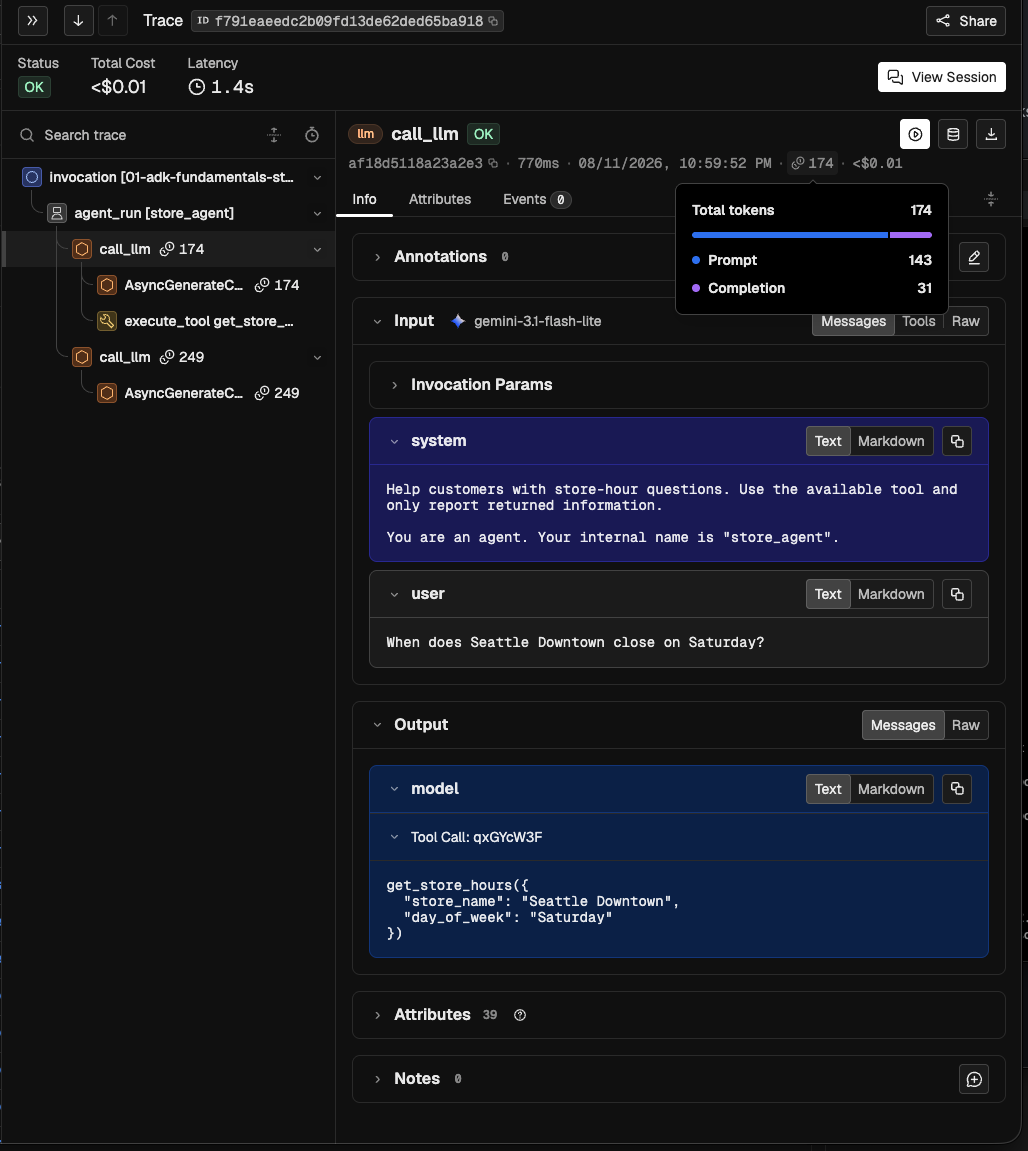

**What to notice**

Model call 1 returns a structured function-call request: it chooses `get_store_hours` and supplies structured arguments.

**Takeaway:** The first LLM call decides what to do; it does not answer the customer yet.

#### 🔎 Store agent tool definition

        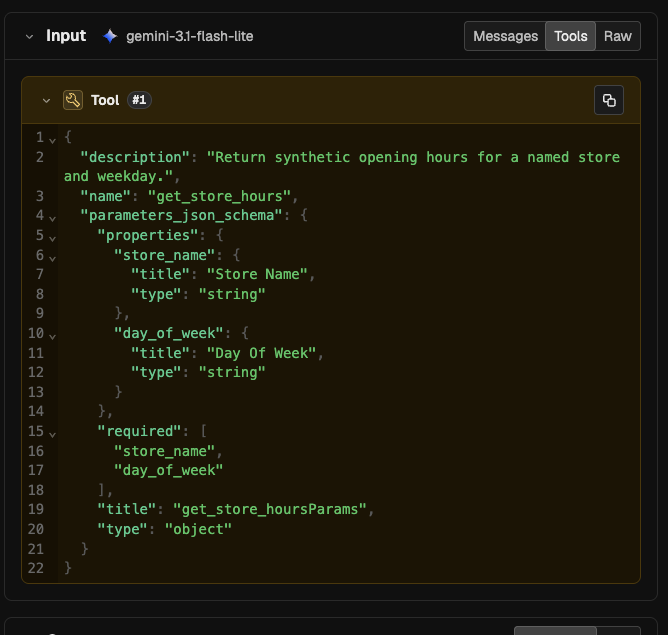

        **What to notice**

        The model context includes only the tool name, description, and JSON input schema before the model chooses how to call it.

The model does not know whether the tool uses an API, a database, or an internal lookup.

        **Takeaway:** Good tool names, descriptions, and schemas are the complete interface the model reasons over.

The tool returns the store-hours record, which is appended to the message history before model call 2 reads it and writes the grounded answer.

#### 🔎 Store agent grounded answer

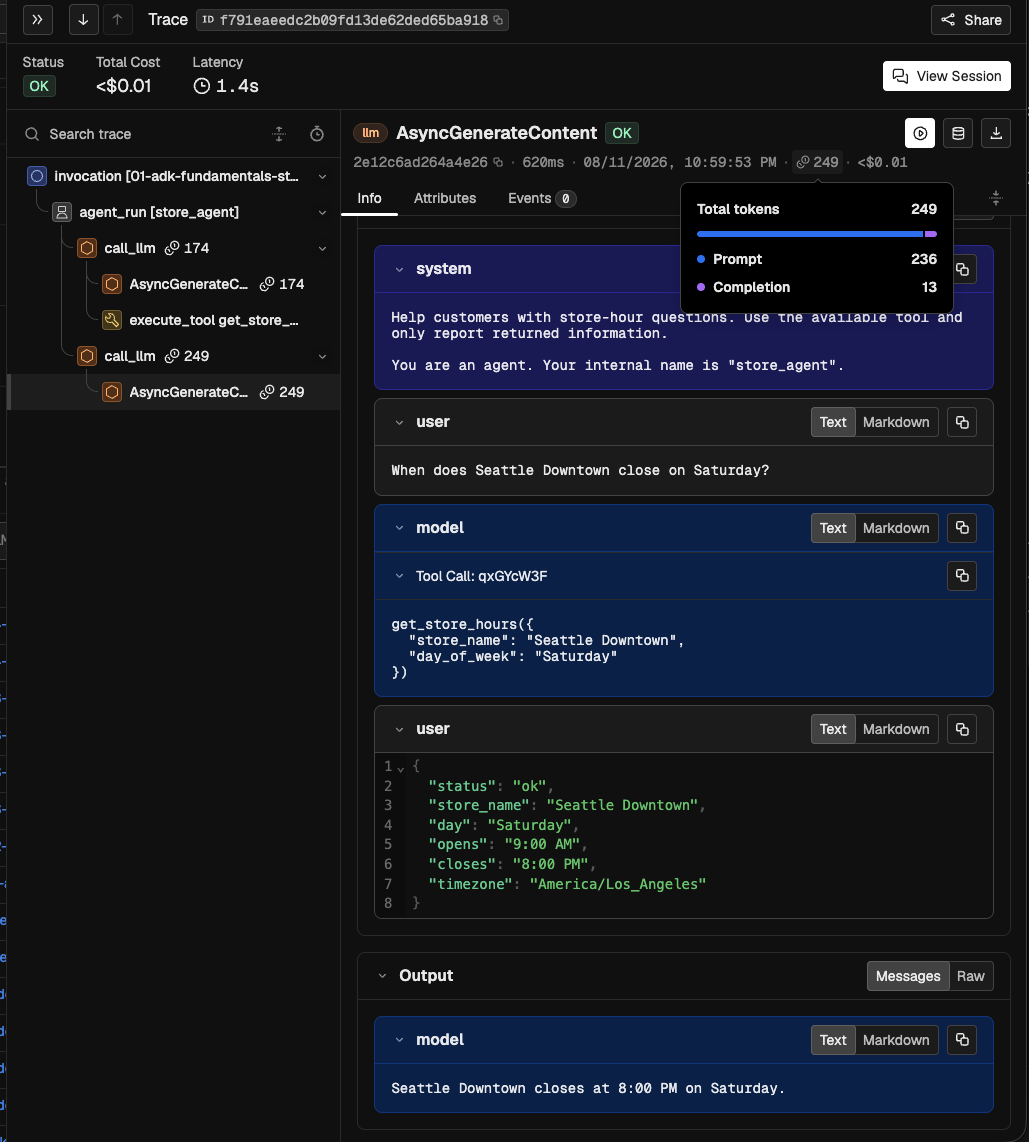

**What to notice**

Model call 2 reads the returned store hours and writes the grounded answer.

**Takeaway:** The tool result becomes message history, allowing the second LLM call to answer from evidence.

## Trace-reading recap

- **Calls:** 2 LLM calls and 1 tool call
- **Model call 1:** 174 total tokens = 143 prompt + 31 completion
- **Model call 2:** 249 total tokens = 236 prompt + 13 completion

The tool call itself has no LLM prompt/completion split.

## ✅ Checkpoint

Nice work—you built and traced a grounded ADK agent. That small loop is the
foundation for everything that follows.